# Quantum walk feature expansion

A discrete-time quantum walk used as a feature-expansion mechanism for binary
classification on Breast Cancer Wisconsin, compared against classical baselines.

Pure NumPy state-vector simulation — no Qiskit, no Pennylane. One independent
walk per dataset row.

```
features -> select k -> scale to parameter ranges -> map to walk parameters
         -> build |psi_0> -> run T steps -> extract features -> ML model
```

This notebook drives the `qw` package rather than restating it, so the physics
and the leakage guarantees are the same ones the test suite checks.

## Fixed physics

Taken from the challenge spec and not modified:

$$C(a,b) = \begin{pmatrix} \cos a\, e^{ib} & \sin a \\ -\sin a & \cos a\, e^{-ib} \end{pmatrix}$$

$$|\text{coin}_0\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$$

$$|\psi_{t+1}\rangle = S\,C\,|\psi_t\rangle, \qquad P_T(x) = \sum_c |\langle x,c|\psi_T\rangle|^2$$

Coin $|0\rangle$ moves left, coin $|1\rangle$ moves right. Ranges:
$\theta\in[0,\pi]$, $\phi\in[0,2\pi]$, $\alpha\in[0,\pi]$, $\beta\in[0,2\pi]$.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qw.config import ExperimentConfig
from qw.data import load_breast_cancer_split
from qw.mapping import QuantumWalkFeatures
from qw.spaces import SPACES, build_space, materialize
from qw.evaluate import evaluate_space, format_results_table
from qw.walk1d import (
    FEATURE_NAMES,
    extract_features,
    position_axis,
    position_probabilities,
    run_qw_1d,
)

plt.rcParams.update({"figure.figsize": (9, 4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

## 2. Configuration

Every knob lives in one frozen dataclass. Nothing below reads a literal seed,
step count or parameter count.

In [2]:
cfg = ExperimentConfig(n_steps=30, permutation=(0, 1, 2, 3), selector="mutual_info")
print(cfg.summary())
print()
print("walk parameters:", cfg.spec.param_names)
print("ranges:         ", [(round(lo, 3), round(hi, 3)) for lo, hi in cfg.spec.param_ranges])
print("features out:   ", cfg.spec.n_features_out)

walk=1d T=30 k=4 selector=mutual_info model=logreg seed=42 perm=[0, 1, 2, 3] [theta<-f0 phi<-f1 alpha<-f2 beta<-f3]

walk parameters: ('theta', 'phi', 'alpha', 'beta')
ranges:          [(0.0, 3.142), (0.0, 6.283), (0.0, 3.142), (0.0, 6.283)]
features out:    10


## 3. Data

One stratified split, seeded, shared by all four feature spaces. The test arrays
below are never handed to any `fit`.

In [3]:
data = load_breast_cancer_split(cfg)
print(data.summary())
print("classes:", data.target_names)

train=426 test=143 features=30 positive_rate: train=0.627 test=0.629
classes: (np.str_('malignant'), np.str_('benign'))


## 4. Feature selection and parameter mapping

`QuantumWalkFeatures` owns the selector and the `MinMaxScaler` and fits both in
`fit()`. Test rows only ever reach `transform()`.

In [4]:
qw = QuantumWalkFeatures(spec=cfg.spec, n_steps=cfg.n_steps,
                         permutation=cfg.permutation, selector=cfg.selector, seed=cfg.seed)
qw.fit(data.X_train, data.y_train)

print(qw.describe())
print()
for name, idx in zip(cfg.spec.param_names, [qw.indices_[s] for s in qw.permutation_]):
    print(f"  {name:<6} <- x{idx:<3} {data.feature_names[idx]}")

selector=mutual_info selected=[7, 20, 22, 23] perm=[0, 1, 2, 3] [theta<-x7 phi<-x20 alpha<-x22 beta<-x23] T=30

  theta  <- x7   mean concave points
  phi    <- x20  worst radius
  alpha  <- x22  worst perimeter
  beta   <- x23  worst area


In [5]:
params_train = qw.walk_parameters(data.X_train)
params_test = qw.walk_parameters(data.X_test)

print("walk parameters per row (train):", params_train.shape)
for i, (name, (lo, hi)) in enumerate(zip(cfg.spec.param_names, cfg.spec.param_ranges)):
    col = params_train[:, i]
    print(f"  {name:<6} range [{lo:.3f}, {hi:.3f}]  observed [{col.min():.3f}, {col.max():.3f}]")

# clip=True keeps test rows inside the declared ranges without refitting on them
assert all(params_test[:, i].min() >= lo - 1e-12 and params_test[:, i].max() <= hi + 1e-12
           for i, (lo, hi) in enumerate(cfg.spec.param_ranges))
print("\ntest rows stay inside every declared range")

walk parameters per row (train): (426, 4)
  theta  range [0.000, 3.142]  observed [0.000, 3.142]
  phi    range [0.000, 6.283]  observed [0.000, 6.283]
  alpha  range [0.000, 3.142]  observed [0.000, 3.142]
  beta   range [0.000, 6.283]  observed [0.000, 6.283]

test rows stay inside every declared range


## 5. The walk

Two rows of the dataset, one per class, become two different walks. The final
position distribution $P_T(x)$ is the readout.

psi shape: (426, 61, 2) (n_samples, n_positions, 2)
norm deviation (max): 8.659739592076221e-15


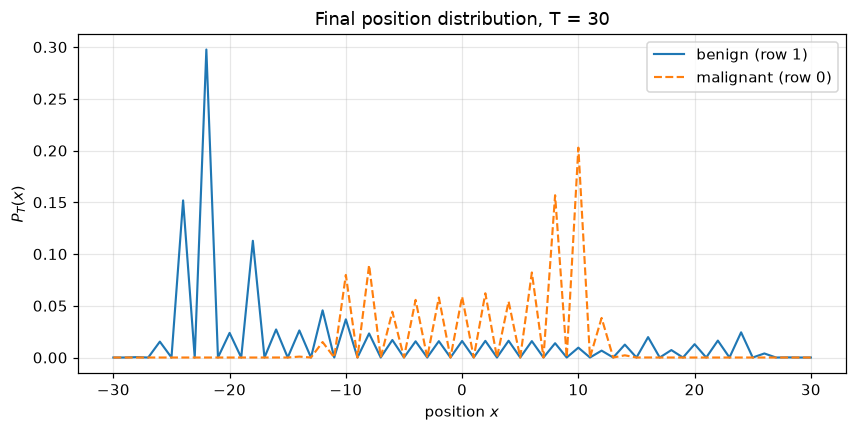

In [6]:
psi_train = cfg.spec.run(params_train, cfg.n_steps)
prob = position_probabilities(psi_train)
x = position_axis(prob.shape[1])

print("psi shape:", psi_train.shape, "(n_samples, n_positions, 2)")
print("norm deviation (max):", np.abs(prob.sum(axis=1) - 1.0).max())

benign = np.where(data.y_train == 1)[0][0]
malignant = np.where(data.y_train == 0)[0][0]

fig, ax = plt.subplots()
for idx, label, style in [(benign, data.target_names[1], "-"), (malignant, data.target_names[0], "--")]:
    ax.plot(x, prob[idx], style, lw=1.4, label=f"{label} (row {idx})")
ax.set_xlabel("position $x$"); ax.set_ylabel("$P_T(x)$")
ax.set_title(f"Final position distribution, T = {cfg.n_steps}")
ax.legend(); plt.show()

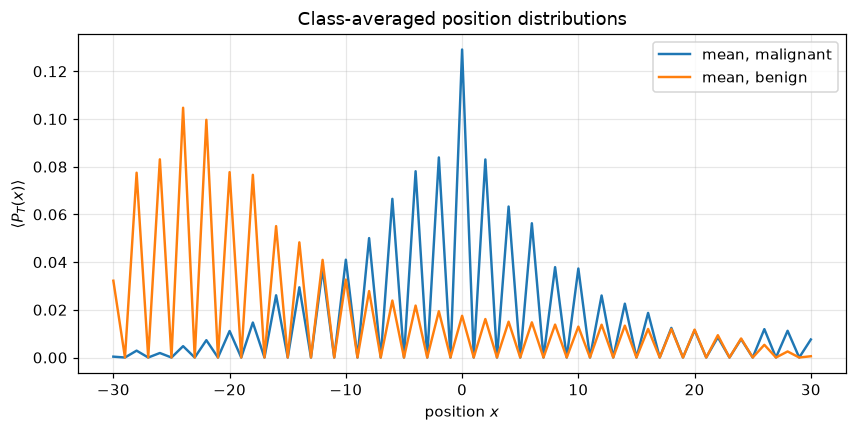

In [7]:
# Class-averaged distributions: what the classifier actually has to separate.
fig, ax = plt.subplots()
for cls, name in enumerate(data.target_names):
    ax.plot(x, prob[data.y_train == cls].mean(axis=0), lw=1.6, label=f"mean, {name}")
ax.set_xlabel("position $x$"); ax.set_ylabel(r"$\langle P_T(x) \rangle$")
ax.set_title("Class-averaged position distributions")
ax.legend(); plt.show()

### Sanity check: the Hadamard walk

$\alpha=\pi/4$, $\beta=0$, $\theta=0$, $\phi=0$ is the Hadamard-like walk from
$|0\rangle$. It is ballistic and left-asymmetric, peaking near $-T/\sqrt{2}$.
Parity restricts support to even sites at even $T$, so the discrete peak lands
at $x=-20$ for $T=30$.

peak at x = -20   target -0.7*T = -21.0   -T/sqrt(2) = -21.21
norm = 1.000000000000   edges = 9.31322574615479e-10, 9.31322574615479e-10  (no wraparound)


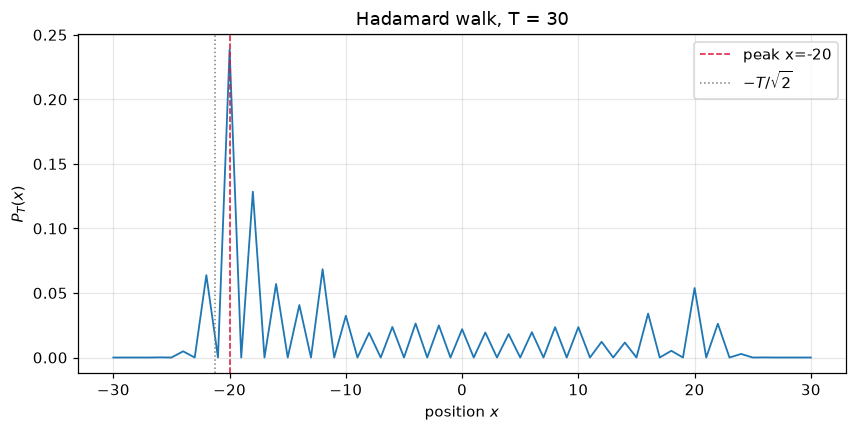

In [8]:
T = 30
zero = np.array([0.0])
psi_h = run_qw_1d(zero, zero, np.array([np.pi / 4]), zero, T)
p_h = position_probabilities(psi_h)[0]
x_h = position_axis(p_h.shape[0])
peak = x_h[np.argmax(p_h)]

print(f"peak at x = {peak:.0f}   target -0.7*T = {-0.7 * T:.1f}   -T/sqrt(2) = {-T / np.sqrt(2):.2f}")
print(f"norm = {p_h.sum():.12f}   edges = {p_h[0]}, {p_h[-1]}  (no wraparound)")

fig, ax = plt.subplots()
ax.plot(x_h, p_h, lw=1.2)
ax.axvline(peak, color="crimson", ls="--", lw=1, label=f"peak x={peak:.0f}")
ax.axvline(-T / np.sqrt(2), color="gray", ls=":", lw=1, label=r"$-T/\sqrt{2}$")
ax.set_xlabel("position $x$"); ax.set_ylabel("$P_T(x)$")
ax.set_title(f"Hadamard walk, T = {T}")
ax.legend(); plt.show()

## 6. Feature extraction

Each distribution collapses to 10 numbers.

In [9]:
feats = extract_features(psi_train)
print("extracted:", feats.shape)
print()
header = f"{'feature':<10}{'mean(benign)':>14}{'mean(malignant)':>17}"
print(header); print("-" * len(header))
for j, name in enumerate(FEATURE_NAMES):
    print(f"{name:<10}{feats[data.y_train == 1, j].mean():>14.4f}"
          f"{feats[data.y_train == 0, j].mean():>17.4f}")

extracted: (426, 10)

feature     mean(benign)  mean(malignant)
-----------------------------------------
mean            -13.7647           0.1679
std              12.6218           7.2739
skew              1.5435-11840540461696.4492
kurtosis          4.741823736214440672605521422843904.0000
entropy           2.4609           2.0836
ipr               0.1606           0.2055
p_max             0.3151           0.3354
argmax_x        -22.0824           0.1887
p_left            0.8213           0.4551
p_origin          0.0175           0.1291


## 7. The four feature spaces

Identical model, split, seed and metrics throughout. The only thing that varies
is the feature matrix.

In [10]:
for space in SPACES:
    Z_tr, Z_te = materialize(space, cfg, data.X_train, data.y_train, data.X_test)
    print(f"{space:<14} train {str(Z_tr.shape):<14} test {Z_te.shape}")

original       train (426, 30)      test (143, 30)
polynomial     train (426, 495)     test (143, 495)
qw             train (426, 10)      test (143, 10)
original+qw    train (426, 40)      test (143, 40)


In [11]:
results = [evaluate_space(space, data, cfg) for space in SPACES]
print(format_results_table(results))

space           dims   accuracy       f1  precision   recall
------------------------------------------------------------
original          30     0.9860   0.9889     0.9889   0.9889 *
polynomial       495     0.9790   0.9836     0.9677   1.0000
qw                10     0.9161   0.9341     0.9239   0.9444
original+qw       40     0.9860   0.9889     0.9889   0.9889 *


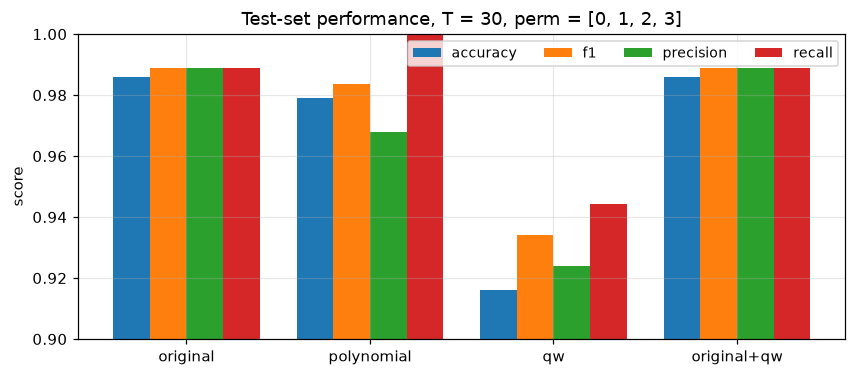

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.6))
metrics = ["accuracy", "f1", "precision", "recall"]
width, pos = 0.2, np.arange(len(SPACES))
for i, m in enumerate(metrics):
    ax.bar(pos + i * width, [getattr(r.metrics, m) for r in results], width, label=m)
ax.set_xticks(pos + 1.5 * width); ax.set_xticklabels([r.space for r in results])
ax.set_ylim(0.90, 1.0); ax.set_ylabel("score")
ax.set_title(f"Test-set performance, T = {cfg.n_steps}, perm = {list(cfg.permutation)}")
ax.legend(ncol=4, fontsize=9); plt.show()

## 8. Permutation search

Which feature drives which parameter is a free choice: $4! = 24$ of them. The
search runs by cross-validation **on the training set only**; the held-out score
is read once, for the winner.

Choosing the permutation by test score instead would inflate the result — on
this split, the best test score over the same 24 is 0.9930 against the 0.9860
the honest procedure gives. That gap is selection leakage, not signal.

In [13]:
from itertools import permutations
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from qw.evaluate import make_model

search = GridSearchCV(
    Pipeline([("space", build_space("original+qw", cfg)), ("model", make_model(cfg.model, cfg.seed))]),
    param_grid={"space__qw__permutation": list(permutations(range(cfg.spec.n_params)))},
    scoring="accuracy",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.seed),
    n_jobs=-1,
)
search.fit(data.X_train, data.y_train)

best = tuple(search.best_params_["space__qw__permutation"])
print(f"best permutation: {list(best)}  [{cfg.spec.describe_permutation(best)}]")
print(f"cv accuracy:      {search.best_score_:.4f}  (train only)")

best permutation: [3, 1, 0, 2]  [theta<-f3 phi<-f1 alpha<-f0 beta<-f2]
cv accuracy:      0.9766  (train only)


In [14]:
best_cfg = ExperimentConfig(n_steps=cfg.n_steps, permutation=best, selector=cfg.selector)
print(format_results_table([evaluate_space(s, data, best_cfg) for s in SPACES]))

space           dims   accuracy       f1  precision   recall
------------------------------------------------------------
original          30     0.9860   0.9889     0.9889   0.9889 *
polynomial       495     0.9790   0.9836     0.9677   1.0000
qw                10     0.9161   0.9348     0.9149   0.9556
original+qw       40     0.9860   0.9889     0.9889   0.9889 *


## 9. Effect of T

The step count sets how far the walk spreads and how much structure the ten
summary features can carry.

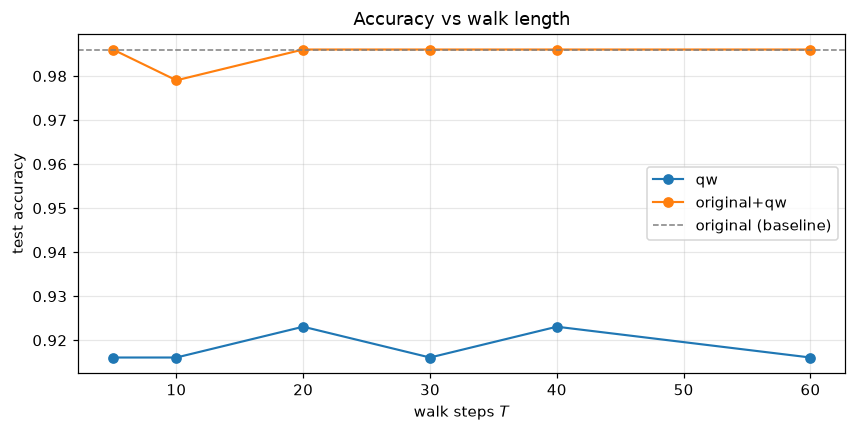

In [15]:
steps_grid = [5, 10, 20, 30, 40, 60]
curve = {"qw": [], "original+qw": []}
for T_i in steps_grid:
    cfg_i = ExperimentConfig(n_steps=T_i, permutation=cfg.permutation, selector=cfg.selector)
    for space in curve:
        curve[space].append(evaluate_space(space, data, cfg_i).metrics.accuracy)

baseline = evaluate_space("original", data, cfg).metrics.accuracy
fig, ax = plt.subplots()
for space, ys in curve.items():
    ax.plot(steps_grid, ys, "o-", lw=1.4, label=space)
ax.axhline(baseline, color="gray", ls="--", lw=1, label="original (baseline)")
ax.set_xlabel("walk steps $T$"); ax.set_ylabel("test accuracy")
ax.set_title("Accuracy vs walk length"); ax.legend(); plt.show()

## Notes

- The quantum-walk space alone (10 dimensions) trails the raw 30 features, and
  concatenating the two ties the baseline rather than beating it. The
  permutation search does not change that once it is scored honestly.
- Remaining knobs for the 1D case: $T$, the selector, and the classifier.
- **2D is not implemented.** Adding it means writing `qw/walk2d.py` with 10
  parameters, two coins and the $\mu/\chi$ entangled initial state, then one
  line in `qw/registry.py`. Selection, mapping, spaces, evaluation and this
  notebook all read `spec.n_params` and `spec.param_ranges`, so nothing here
  needs rewriting.